# Block 13 — LAB: Ensembles — Bagging, Built by Hand (SOLUTION)
### Advanced Machine Learning — M&T Bank

**Dataset:** `bank_marketing_features.csv` (unchanged since Day 1, Block 3). Same target/split as Block 12. No new
CSV comes out of this lab.

Block 12 showed *that* ensembles can beat a simple benchmark. This lab shows *why* bagging specifically works —
by building one from scratch, one bootstrap sample at a time, before checking the result against scikit-learn's
optimized version.

Three parts:
1. **The problem** — how much do two independently-bootstrapped decision trees actually disagree?
2. **The fix** — average many of them, and watch accuracy climb as the ensemble grows
3. **The sanity check** — does the from-scratch version match `BaggingClassifier`? Does `RandomForestClassifier`'s
   extra randomness (feature subsampling per split) add anything on top of plain bagging, on this dataset?


## Setup

In [ ]:
import warnings
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)

NAVY = "#251E4E"
PINK = "#FF1675"
GRAY = "#6b7280"
ORANGE = "#FF7B01"

# Data source: https://raw.githubusercontent.com/mithun-rk/mt-advml-course/main/Data/bank_marketing_features.csv
df = pd.read_csv("https://raw.githubusercontent.com/mithun-rk/mt-advml-course/main/Data/bank_marketing_features.csv", sep=";")
feature_cols = [c for c in df.columns if c not in ("education", "y", "duration")]
bool_cols = [c for c in df[feature_cols].columns if df[c].dtype == bool]
X = df[feature_cols].copy()
for c in bool_cols:
    X[c] = X[c].astype(int)
y = df["y"].values

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
Xtr_arr = Xtr.values
n = len(Xtr_arr)
print(f"Train: {n} rows. Test: {len(Xte)} rows.")


## Part 1 — How Much Do Two Trees Actually Disagree?

Fit two unlimited-depth decision trees, each on its own bootstrap resample of the training set (sample `n` rows
with replacement — that's what makes it a *bootstrap*, not just a re-shuffle).


In [2]:
rng1 = np.random.RandomState(0)
idx1 = rng1.choice(n, size=n, replace=True)
dt1 = DecisionTreeClassifier(random_state=0)
dt1.fit(Xtr_arr[idx1], ytr[idx1])

rng2 = np.random.RandomState(1)
idx2 = rng2.choice(n, size=n, replace=True)
dt2 = DecisionTreeClassifier(random_state=1)
dt2.fit(Xtr_arr[idx2], ytr[idx2])

pred1, pred2 = dt1.predict(Xte), dt2.predict(Xte)
proba1, proba2 = dt1.predict_proba(Xte)[:, 1], dt2.predict_proba(Xte)[:, 1]

agree_rate = (pred1 == pred2).mean()
corr = np.corrcoef(proba1, proba2)[0, 1]
print(f"Classification agreement (0.5 threshold): {agree_rate:.1%}")
print(f"Correlation between predicted probabilities: {corr:.3f}")


Classification agreement (0.5 threshold): 84.8%
Correlation between predicted probabilities: 0.317


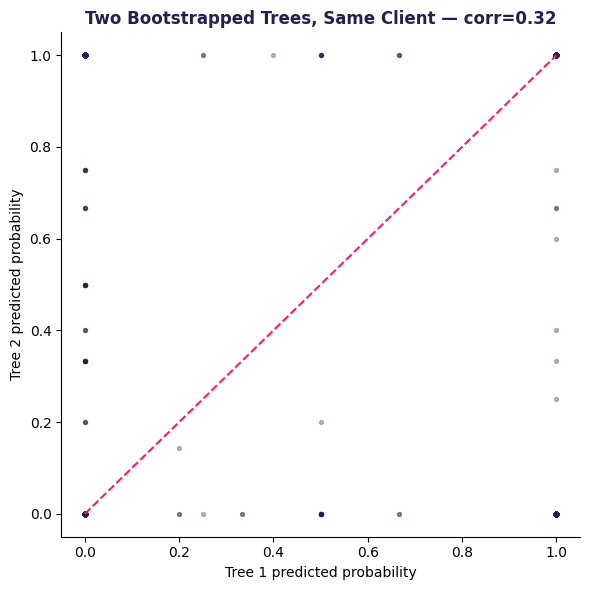

In [3]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(proba1, proba2, s=8, alpha=0.3, color=NAVY)
ax.plot([0, 1], [0, 1], color=PINK, linestyle="--", linewidth=1.5)
ax.set_xlabel("Tree 1 predicted probability")
ax.set_ylabel("Tree 2 predicted probability")
ax.set_title(f"Two Bootstrapped Trees, Same Client — corr={corr:.2f}", color=NAVY, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


**Two trees, same training data pool, same modeling choices — different bootstrap samples produce noticeably
different opinions about the same clients.** That gap between two individually-trained trees is exactly the
"noise" bagging is designed to average away.


## Part 2 — Does Averaging Actually Fix It?

Build bagging from scratch: fit `B` decision trees, each on its own bootstrap sample, and average their predicted
probabilities. Sweep `B` and watch what happens to test-set ROC-AUC.


In [4]:
def manual_bagging_proba(B, seed0=0):
    probas = np.zeros(len(Xte))
    for b in range(B):
        rng_b = np.random.RandomState(seed0 + b)
        idx = rng_b.choice(n, size=n, replace=True)
        dt = DecisionTreeClassifier(random_state=seed0 + b)
        dt.fit(Xtr_arr[idx], ytr[idx])
        probas += dt.predict_proba(Xte)[:, 1]
    return probas / B

bagging_rows = []
for B in [1, 5, 25, 100]:
    t0 = time.time()
    proba = manual_bagging_proba(B)
    auc = roc_auc_score(yte, proba)
    bagging_rows.append({"B (number of trees)": B, "Test ROC-AUC": round(auc, 4),
                          "Fit time (s)": round(time.time() - t0, 1)})
pd.DataFrame(bagging_rows)


,B (number of trees),Test ROC-AUC,Fit time (s)
0,1,0.6227,0.3
1,5,0.7251,1.2
2,25,0.7610,5.9
3,100,0.7715,21.5


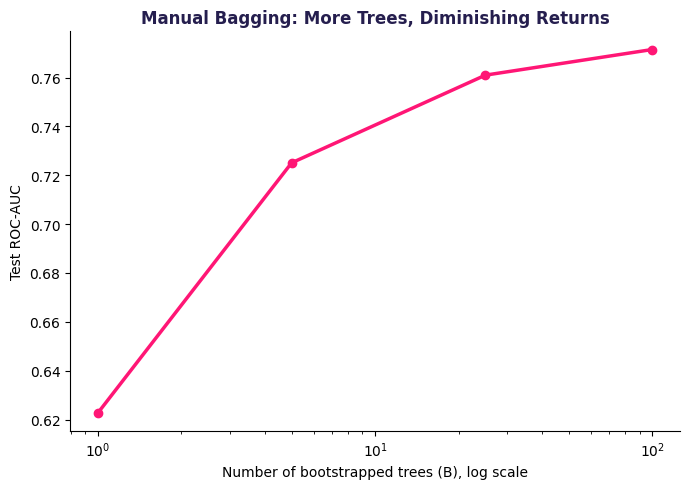

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
Bs = [r["B (number of trees)"] for r in bagging_rows]
aucs = [r["Test ROC-AUC"] for r in bagging_rows]
ax.plot(Bs, aucs, marker="o", color=PINK, linewidth=2.5)
ax.set_xscale("log")
ax.set_xlabel("Number of bootstrapped trees (B), log scale")
ax.set_ylabel("Test ROC-AUC")
ax.set_title("Manual Bagging: More Trees, Diminishing Returns", color=NAVY, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


**A single unlimited-depth tree scores 0.62 — worse than a coin flip's worth of useful signal compared to Block
6's logistic benchmark (0.796). Averaging 100 of them reaches 0.77, most of the way to Block 12's tuned ensemble
results, with clearly diminishing returns past ~25 trees.** Nothing about any individual tree changed — the entire
gain came from averaging away the disagreement quantified in Part 1.


## Part 3 — Sanity Check: Does This Match scikit-learn?

`BaggingClassifier` does exactly what Part 2 built by hand, just vectorized and parallelized. `RandomForestClassifier`
adds one more source of randomness on top: each split only considers a random subset of features, not all of them.


In [6]:
bag = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42), n_estimators=100,
                         random_state=42, n_jobs=-1)
bag.fit(Xtr, ytr)
bag_auc = roc_auc_score(yte, bag.predict_proba(Xte)[:, 1])

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(Xtr, ytr)
rf_auc = roc_auc_score(yte, rf.predict_proba(Xte)[:, 1])

pd.DataFrame({
    "Model": ["Manual bagging (B=100, from Part 2)", "sklearn BaggingClassifier (100 trees)",
              "sklearn RandomForestClassifier (100 trees)"],
    "Test ROC-AUC": [bagging_rows[-1]["Test ROC-AUC"], bag_auc, rf_auc],
}).round(4)


,Model,Test ROC-AUC
0,"Manual bagging (B=100, from Part 2)",0.7715
1,sklearn BaggingClassifier (100 trees),0.7741
2,sklearn RandomForestClassifier (100 trees),0.7737


**The from-scratch version (0.7715) lands right next to `BaggingClassifier` (0.7741) — confirming the manual
implementation was doing the real thing, not something that only looked similar.** More interesting: on this
particular dataset, `RandomForestClassifier`'s extra per-split feature subsampling (0.7737) doesn't beat plain
bagging in any meaningful way. That's a real, honest result, not a disappointing one — feature subsampling earns
its keep most when a dataset has many *strongly correlated* features that would otherwise dominate every split
identically (this dataset does have some — the macro `_denoised` siblings), but the effect wasn't large enough
here to separate the two methods. Worth knowing bagging's variance-reduction mechanism doesn't automatically need
Random Forest's extra machinery to work.


## Wrap-Up

- Two independently-bootstrapped trees agreed on only 84.8% of classifications and correlated at just 0.32 on
  probabilities — genuine disagreement, not a rounding error.
- Averaging many of them (bagging) turned a weak single tree (AUC 0.62) into a competitive ensemble (AUC 0.77),
  with diminishing returns past roughly 25-100 trees.
- This is Block 5's variance-reduction lesson from a different angle: there, five-fold CV averaged five *estimates*
  of performance to get a stable number; here, bagging averages many *models* to get a stable prediction. Same
  underlying idea — averaging independent-ish things reduces variance — applied to two different problems.

**Next: Block 14** — heterogeneous ensembles (combining *different* model types) and a final verdict on whether
today's added complexity earned its keep.
